# Chapter 11: The Crowd and the Ox
This is a synthetic crowd, not Galton's original ticket data. Compare aggregation
with correlated errors and outliers; independence and diversity have consequences.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from scipy.stats import trim_mean
rng=begin(11); truth=1200.; guesses=truth+rng.normal(0,180,800)

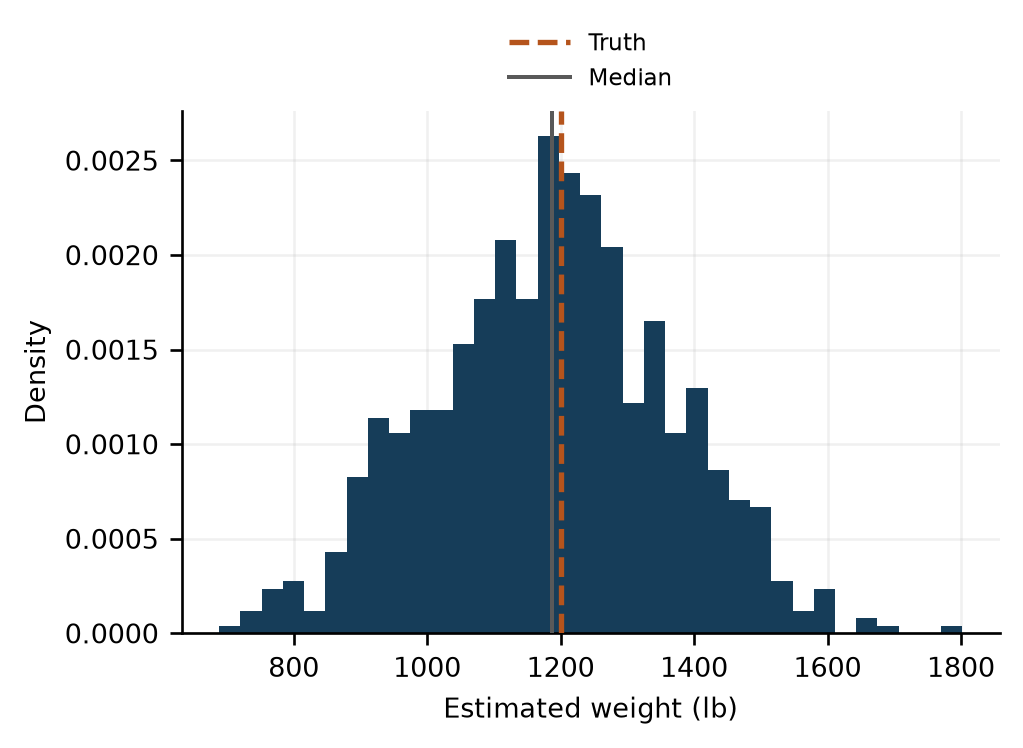

In [2]:
plt.figure(); plt.hist(guesses,bins=35,density=True); plt.axvline(truth,ls='--',color='#b5541c',lw=1.6,zorder=3,label='Truth'); plt.axvline(np.median(guesses),color='0.35',lw=1.2,zorder=3,label='Median'); plt.xlabel('Estimated weight (lb)'); plt.ylabel('Density'); plt.legend()
save(11,1,'Individual error can coexist with a good aggregate','Eight hundred synthetic weight estimates centered on 1,200 lb. This does not reproduce the historical ox competition.','## Surowiecki\'s Framework')

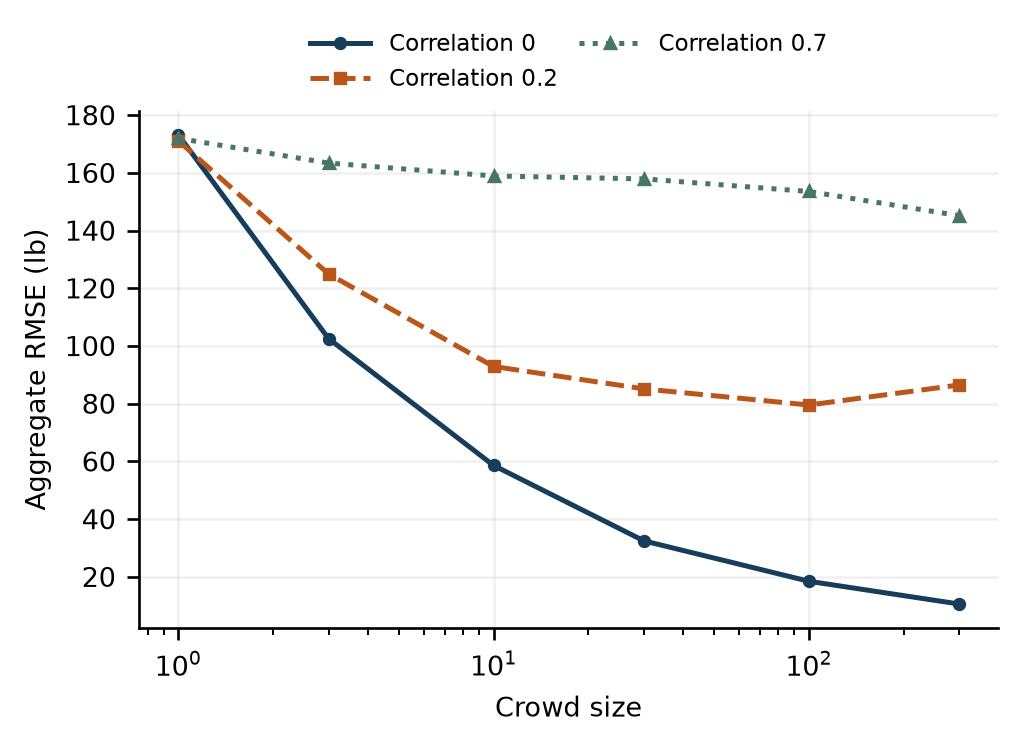

In [3]:
sizes=np.array([1,3,10,30,100,300]); plt.figure()
for rho in [0,.2,.7]:
    rmse=[]
    for n in sizes:
        errors=180*(np.sqrt(rho)*rng.normal(size=(400,1))+np.sqrt(1-rho)*rng.normal(size=(400,n)))
        rmse.append(np.sqrt(np.mean(errors.mean(axis=1)**2)))
    plt.plot(sizes,rmse,'o-',label=f'Correlation {rho}')
plt.xscale('log'); plt.xlabel('Crowd size'); plt.ylabel('Aggregate RMSE (lb)'); plt.legend(fontsize=7)
save(11,2,'Common error sets a floor','Repeated synthetic panels with correlated individual errors. Larger groups cannot eliminate a common component.','## The Full Machinery')

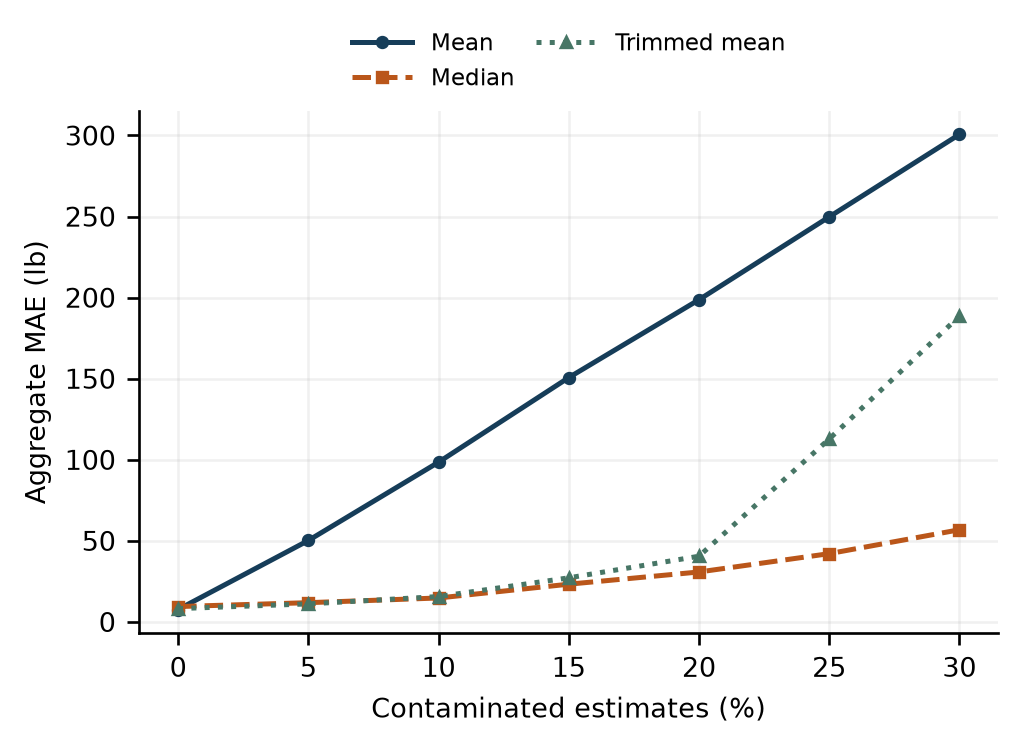

In [4]:
fractions=np.arange(0,.31,.05); results={name:[] for name in ['Mean','Median','Trimmed mean']}
for fraction in fractions:
    sample=truth+rng.normal(0,100,(300,100)); sample[:,:int(fraction*100)]+=1000
    for name,estimate in zip(results,[sample.mean(axis=1),np.median(sample,axis=1),trim_mean(sample,.2,axis=1)]): results[name].append(np.mean(abs(estimate-truth)))
plt.figure()
for name,values in results.items(): plt.plot(fractions*100,values,'o-',label=name)
plt.xlabel('Contaminated estimates (%)'); plt.ylabel('Aggregate MAE (lb)'); plt.legend(fontsize=7)
save(11,3,'Robustness depends on the contamination','Synthetic panels with upward outliers. The 20% trimmed mean removes each tail; its robustness is limited as contamination increases.','## The Room Your Organization Is In')

## Limits and exercise
Change outliers to shared moderate bias. A median resists extreme values but
cannot fix a biased crowd. Estimated precision weights may overfit; compare them
against equal weights on new events before adopting them.

## Can estimated weights beat equal weights on later questions?
Here the synthetic experts have persistently different noise scales. Learn
inverse-MSE weights on 80 earlier resolved questions, freeze them, and score 40
later questions. A small training set or changing expert performance can reverse
this advantage. The weights are not selected after seeing the test outcomes.

In [5]:
event_truth=rng.normal(100,20,120); expert_scale=np.linspace(5,30,8)
event_guesses=event_truth[:,None]+rng.normal(size=(120,8))*expert_scale
training_mse=np.mean((event_guesses[:80]-event_truth[:80,None])**2,axis=0)
weights=(1/training_mse)/(1/training_mse).sum()
equal=event_guesses[80:].mean(axis=1); weighted=event_guesses[80:]@weights
print({'learned_weights':weights.round(3).tolist(),'equal_test_MAE':float(abs(equal-event_truth[80:]).mean()),'weighted_test_MAE':float(abs(weighted-event_truth[80:]).mean())})
print('Interpretation: this generator supplies persistent expert skill differences. Correlated errors or a change in skill require a different weighting argument.')

{'learned_weights': [0.626, 0.169, 0.065, 0.06, 0.028, 0.02, 0.017, 0.015], 'equal_test_MAE': 4.811004995608605, 'weighted_test_MAE': 3.31054273765515}
Interpretation: this generator supplies persistent expert skill differences. Correlated errors or a change in skill require a different weighting argument.


<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
CSV question,expert,estimate,actual; one independent initial estimate per expert/question, actual finite for CLI scoring; keep unresolved estimates separately. Document units and any elicitation order. Do not mix probability and quantity estimates.

Minimal **format illustration**, not sufficient training data:

```csv
question,expert,estimate,actual
Q1,E1,90,100
Q1,E2,110,100
Q1,E3,1000,100
```

## Explain the mechanism

Crowd wisdom depends on the error structure. Diversity of labels or biographies does not guarantee diversity of information. Robust aggregators protect against particular contamination patterns; their usefulness must match the actual errors.

## Work through the arithmetic

For [90,100,110,1000], the mean is 325 and the median is 105. A 25% trim from each tail leaves [100,110], mean 105. With individual SD=10, rho=.2 and n=10, aggregate SD is sqrt(100(.2+.8/10))=sqrt(28)=5.292; it does not fall to 10/sqrt(10)=3.162.

## Adapt the lesson to reader data

Replace guesses or the repeated panel with question-level observed estimates. Keep resolved questions separate from open ones. If comparing trim levels, choose them on earlier resolved questions and preserve the later event set for assessment.

For this chapter, settle these questions before fitting: Do estimates share a target, horizon and units? Who saw whose answer? Which sources are common? Are there past resolved questions for testing weights?

## Interpret the actual lesson outputs

The ox distribution is synthetic. The correlation experiment holds individual marginal variance fixed, unlike adding an extra shared noise term without rescaling. The contamination figure injects upward extremes; performance under that mechanism does not establish robustness to shared moderate bias.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `question,actual,mean,median,trimmed`.
- `summary.json`: `mae,brier,extremize_a` plus method, interpretation, assumptions, not_done and status.

The adapter requires resolved question actuals and compares fixed mean, median and 20%-each-tail trimmed mean. When the estimates are event probabilities with binary actuals, `extremize_a` (a positive number, 2.5 is the usual starting value) adds a logit-extremized pool and scores every rule by Brier as well as MAE; extremization helps only when experts share information and the plain pool is too timid, and the tool refuses it on non-probability data. It does not learn weights or turn disagreement into calibrated outcome intervals.

## Decide what the evidence supports

Mean aggregation cancels idiosyncratic error but not common bias. Median robustness to extremes does not correct shared moderate error. With equal individual variance sigma² and correlation rho, mean variance is sigma²[rho+(1-rho)/n].

With few estimates, report each judgment and simple aggregates rather than unstable learned weights. Without resolved outcomes, compare robustness and assumptions only. If everyone shares one source, state that the aggregate contains little independent information.

The applied deliverable must make these items inspectable: `results.csv` columns: `question,actual,mean,median,trimmed`; `summary.json` keys: `mae,brier,extremize_a` plus method, interpretation, assumptions, not_done and status. Return respondent count, mean/median/trimmed estimates, source-dependence notes, outlier sensitivity and held-out aggregation losses if available.

## Three exercises with worked solutions

### Exercise 1

All five estimates are 120 while truth is 100. What do mean and median do?

**Worked solution.** Both remain 120; aggregation cannot remove a shared 20-unit bias.

### Exercise 2

rho=1 and individual SD=20. What is aggregate SD at n=100?

**Worked solution.** 20: perfectly common error does not average away.

### Exercise 3

May the spread of five opinions be called an 80% prediction interval?

**Worked solution.** Not without a justified link between opinion dispersion and outcome uncertainty; call it disagreement or a scenario range.

## Business-reader application

Use this request with the skill:

> Apply chapter 11 to estimates.csv, compare transparent aggregators and explain whether apparent agreement comes from independent information or shared evidence.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [6]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch11.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch11.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(11, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch11-workshop-results.csv', index=False)
_ = (workshop_output/'ch11-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Crowd aggregation rules (mean, median, trimmed mean) scored on identical questions
Status: passed

Interpretation: Over 8 questions the lowest MAE came from the median (7.538); all rules: mean 8.893, median 7.538, trimmed 8.151. Unweighted rules are evaluated on identical questions. Precision weights require earlier resolved questions, and shared bias can defeat every aggregation rule.

Assumptions:
  - Each expert answered every question independently of the others
  - One resolved outcome per question
Not done:
  - No accuracy-weighted combination (needs earlier resolved questions)
  - No test for shared information among experts

Evidence:
  mae: mean=8.893, median=7.538, trimmed=8.151
  brier: None
  extremize_a: None

Table: 8 rows, columns ['question', 'actual', 'mean', 'median', 'trimmed']

 question  actual    mean  median  trimmed
        0     100 108.226 106.586  109.154
        1     110 119.367 117.209  116.546
        2     120 129.249 125.476  125.677
        3  

## Self-check

The three questions a good forecaster asks in this situation. A bad answer to any one of them is a reason to stop and fix the work before reporting.

1. **Are the estimates independent, or did the crowd see each other's numbers?**
   A bad answer looks like this: A crowd that talked first is one estimate with many signatures.

2. **Does the median or trimmed mean tell a different story from the mean, and why?**
   A bad answer looks like this: A mean pulled by two outliers reports the outliers.

3. **What shared bias could every member carry, and how would I detect it?**
   A bad answer looks like this: Averaging does not remove an error everyone makes in the same direction.

Shared rules for every chapter: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).